## Set up data and model objects


In [1]:
import pandas as pd
import numpy as np
import mudata as md
from perturbo import run_svi, run_mcmc, perturbseq_guide_autonormal_turbo, perturbseq_model_turbo, get_covariates_array
import seaborn as sns
import matplotlib.pyplot as plt
import jax.numpy as jnp


test_ntcs = False
controls_only = True

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [2]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [3]:
mdata["rna"].obs["log1p_guide_count"] = np.log1p(mdata["grna"].X.sum(axis=1))

In [4]:
mdata["grna"][:, ["chr11:33966182-33966205|1", "chr11:33966182-33966205|2"]].X.sum(axis=0)

array([112., 415.], dtype=float32)

In [5]:
mdata["grna"]

AnnData object with n_obs × n_vars = 47964 × 3115
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [6]:
# element = "ACTB_TSS"
# element = "ACTG1_TSS"
tss_guides = [x for x in mdata["grna"].var_names if "_TSS" in x]
# element_guides = [x for x in mdata["grna"].var_names if "random" not in x and "scrambled" not in x]
# element_guides = mdata["grna"].varm["element_targeted"][element]
# len(element_guides)

In [7]:
ntc_guides = [x for x in mdata["grna"].var_names if "random" in x or "scrambled" in x]
# len(control_guides)
# control_guides = pd.Series(np.zeros(len(element_guides)), index=element_guides)
# control_guides[-50:] = 1
# control_guides

In [8]:
if controls_only:
    element_guides = tss_guides
else:
    element_guides = [x for x in mdata["grna"].var_names if x not in ntc_guides]
selected_guides = element_guides + ntc_guides
print(len(element_guides), len(ntc_guides), len(selected_guides))

762 100 862


In [9]:
selected_cells = mdata["grna"][:, selected_guides].X.sum(axis=1) > 0
selected_cells.sum()

45053

In [10]:
if test_ntcs:
    grna_subset = mdata["grna"][:, selected_guides]
else:
    grna_subset = mdata["grna"][:, element_guides]
grna_subset = grna_subset[selected_cells, :]
grna_subset

View of AnnData object with n_obs × n_vars = 45053 × 762
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [11]:
mdata["rna"].var_names

Index(['AL627309.1', 'AL627309.5', 'AP006222.1', 'AL732372.2', 'AL669831.3',
       'MTND1P23', 'MTND2P28', 'MTCO1P12', 'AC114498.2', 'MTATP6P1',
       ...
       'TTTY14', 'TTTY10', 'AC024236.1', 'BX004987.1', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.3', 'AC240274.1'],
      dtype='object', length=16367)

In [12]:
# gene = "ACTB"
# genes = ["ACTB", "ACTG1", "MTND1P23"]
genes = sorted({x.split("_")[0] for x in element_guides})
genes = [x for x in genes if x in mdata["rna"].var_names]

len(genes)

373

In [13]:
# genes = mdata["rna"].var_names
rna_subset = mdata["rna"][:, genes]
rna_subset = rna_subset[selected_cells, :]
rna_subset

View of AnnData object with n_obs × n_vars = 45053 × 373
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size', 'log1p_guide_count'
    varm: 'element_tested'

In [14]:
cell_covariates = get_covariates_array(
    rna_subset, columns=["log_total_gene_count", "percent_mito", "log1p_guide_count"]
)
cell_covariates

Array([[8.385716  , 0.0290571 , 3.5553482 ],
       [8.254789  , 0.02597587, 3.1780539 ],
       [8.206857  , 0.04274687, 2.1972246 ],
       ...,
       [8.135054  , 0.02120768, 3.6635616 ],
       [8.204125  , 0.02517777, 2.9957323 ],
       [8.520388  , 0.02861614, 2.5649493 ]], dtype=float32)

In [15]:
mdata_subset = md.MuData({"gene": rna_subset, "guide": grna_subset})
mdata_subset

MuData object with n_obs × n_vars = 45053 × 1135
  2 modalities
    gene:	45053 x 373
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size', 'log1p_guide_count'
      varm:	'element_tested'
    guide:	45053 x 762
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [16]:
gene_obs = jnp.array(rna_subset.X.toarray()).astype(int)
guide_obs = jnp.array(grna_subset.X).astype(bool)
# guide_obs = guide_obs.at[:, 2:].set(0)
guide_obs.shape

(45053, 762)

In [17]:
targeted_in_subset = grna_subset.varm["element_targeted"].sum() > 0
selected_elements = targeted_in_subset[targeted_in_subset].index
guide_target_elements = grna_subset.varm["element_targeted"][selected_elements]
guide_target_elements

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,WDR61_TSS,WSB1_TSS,XPO1_TSS,YWHAE_TSS,YWHAQ_TSS,ZC3H8_TSS,ZNF273_TSS,ZNF593_TSS,ZNHIT1_TSS,ZRANB2_TSS
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF593_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ZNHIT1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZNHIT1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZRANB2_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
import pandas as pd
# gene_idx = 1

# n_plot_genes = min(4, len(genes))
# print(n_plot_genes)
# fig, axs = plt.subplots(3, n_plot_genes, sharex="col")


# # Control histogram
# for gene_idx in range(n_plot_genes):
#     max_count = gene_obs[:, gene_idx].max()
#     n_bins = min(int(max_count) + 1, 50)
#     hist_bins = np.linspace(0, max_count + 1, n_bins)
#     hist_bins = None
#     control_gene_obs = gene_obs[guide_obs.sum(axis=1) == 0, gene_idx].squeeze()
#     axs[0][gene_idx].hist(control_gene_obs, bins=hist_bins, density=True)
#     axs[0][gene_idx].axvline(control_gene_obs.mean(), color="black")
#     axs[0][gene_idx].set_ylabel("Density (control)")
#     axs[0][gene_idx].set_title(genes[gene_idx])

#     # Guide histograms
#     for i in range(2):
#         guide_gene_obs = gene_obs[guide_obs[:, i].astype(bool), gene_idx].squeeze()
#         axs[i + 1][gene_idx].axvline(guide_gene_obs.mean(), color="black")
#         # print(np.log2(guide_gene_obs.mean() / control_gene_obs.mean()))
#         axs[i + 1][gene_idx].hist(guide_gene_obs, bins=hist_bins, density=True)
#         axs[i + 1][gene_idx].set_ylabel(f"Density (guide {i})")
#         # axs[i + 1][gene_idx].set_title(f"")

#     axs[i + 1][gene_idx].set_xlabel("Gene counts per cell")
# plt.tight_layout()
# plt.show()

In [19]:
df_ontarget = pd.DataFrame(
    {"element": selected_elements, "value": 1}, index=selected_elements.str.split("_").str[0]
)
df_ontarget
# Create a dataframe with every combination of row_indices and column_indices
# df_ontarget = pd.DataFrame(0.0, index=mdata["rna"].var_names, columns=selected_elements)
# df_ontarget = df_ontarget.melt(value_name="value", var_name="element", ignore_index=False)
# df_ontarget.loc[df_ontarget.index == df_ontarget["element"].str.split("_").str[0], "value"] = 1

,element,value
ACTB,ACTB_TSS,1
ACTG1,ACTG1_TSS,1
ACYP1,ACYP1_TSS,1
ADIPOR1,ADIPOR1_TSS,1
ALDH1A2,ALDH1A2_TSS,1
...,...,...
ZC3H8,ZC3H8_TSS,1
ZNF273,ZNF273_TSS,1
ZNF593,ZNF593_TSS,1
ZNHIT1,ZNHIT1_TSS,1


In [20]:
element_target_genes = (
    df_ontarget.pivot(columns="element", values="value")
    .reindex(
        index=rna_subset.var_names,
        columns=guide_target_elements.columns,
    )
    .fillna(0)
)
# rna_subset.varm["target_gene"] = element_target_genes
# rna_subset.varm["target_gene"]
element_target_genes
# Set the values of the dataframe equal to one where the row index equals the column index up to the first "_" character
# df_ontarget[df_ontarget.index.str.split('_').str[0] == df_ontarget.columns.str.split('_').str[0]] = 1
# df_ontarget


# Display the dataframe
# df_ontarget

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,WDR61_TSS,WSB1_TSS,XPO1_TSS,YWHAE_TSS,YWHAQ_TSS,ZC3H8_TSS,ZNF273_TSS,ZNF593_TSS,ZNHIT1_TSS,ZRANB2_TSS
ACTB,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADIPOR1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ALDH1A2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZC3H8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
ZNF273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ZNF593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ZNHIT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [21]:
rna_subset

View of AnnData object with n_obs × n_vars = 45053 × 373
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size', 'log1p_guide_count'
    varm: 'element_tested'

In [22]:
element_target_genes.sum()

ACTB_TSS       1.0
ACTG1_TSS      1.0
ACYP1_TSS      1.0
ADIPOR1_TSS    1.0
ALDH1A2_TSS    1.0
              ... 
ZC3H8_TSS      1.0
ZNF273_TSS     1.0
ZNF593_TSS     1.0
ZNHIT1_TSS     1.0
ZRANB2_TSS     1.0
Length: 381, dtype: float64

In [23]:
# assert element_target_genes.columns == mdata["grna"].varm["element_targeted"].columns


break

SyntaxError: 'break' outside loop (1849312666.py, line 4)

In [ ]:
perturbseq_guide = perturbseq_guide_autonormal_turbo()
model_args = (gene_obs,)
model_kwargs = {
    "guide_obs": guide_obs,
    "guide_target_elements": jnp.array(guide_target_elements.values),
    "covariates": cell_covariates_robust_z_scored,
    "element_target_genes": jnp.array(element_target_genes.values).T,
    "likelihood": "NegBin",
    "prior_inclusion_prob": 1e-5,
    "subsample_size": 1024,
    "efficiency_alpha": 5 / 3,
    "efficiency_beta": 5,
    "n_factors": 100,
    "n_cell_factors": 10,
}

svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model_turbo,
    perturbseq_guide,
    n_steps=5000,
)

100%|██████████| 5000/5000 [02:40<00:00, 31.17it/s, init loss: 111247976.0000, avg. loss [4751-5000]: 34618111.5360]


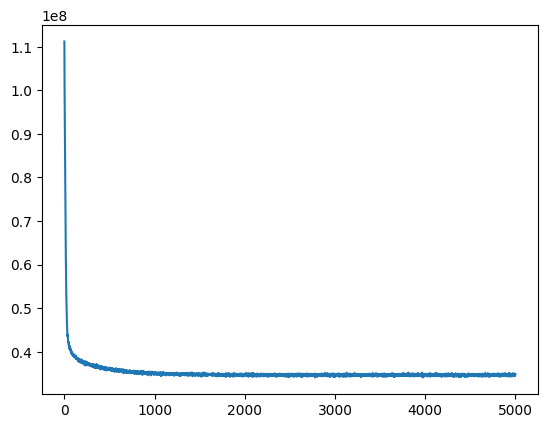

In [ ]:
plt.plot(svi_result.losses)

In [ ]:
params = svi_result.params
params.keys()

dict_keys(['cell_factor_auto_loc', 'cell_factor_auto_scale', 'cell_loading_auto_loc', 'cell_loading_auto_scale', 'covariate_weight_auto_loc', 'covariate_weight_auto_scale', 'dispersion_auto_loc', 'dispersion_auto_scale', 'efficiency_auto_loc', 'efficiency_auto_scale', 'log2_fold_change_auto_loc', 'log2_fold_change_auto_scale', 'mean_auto_loc', 'mean_auto_scale'])

In [ ]:
# perturbseq_guide.median(params)

In [ ]:
for k, v in perturbseq_guide.median(params).items():
    print(k, v.shape)

mean (373,)
dispersion (373,)
efficiency (762, 1)
log2_fold_change (381, 373)
covariate_weight (3, 373)
cell_loading (10, 373)
cell_factor (45053, 10)


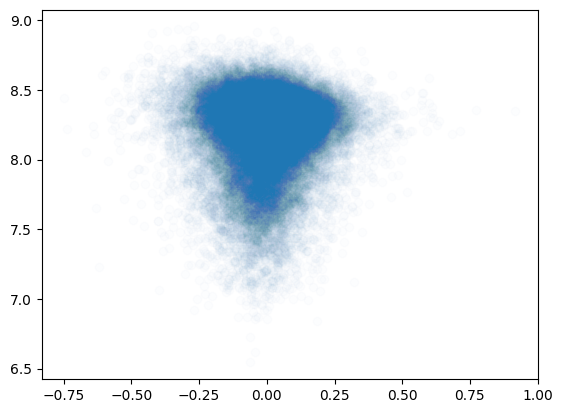

In [ ]:
cell_factors = perturbseq_guide.median(params)["cell_factor"]

plt.scatter(cell_factors[:, 0], cell_covariates[:, 0], alpha=0.01)

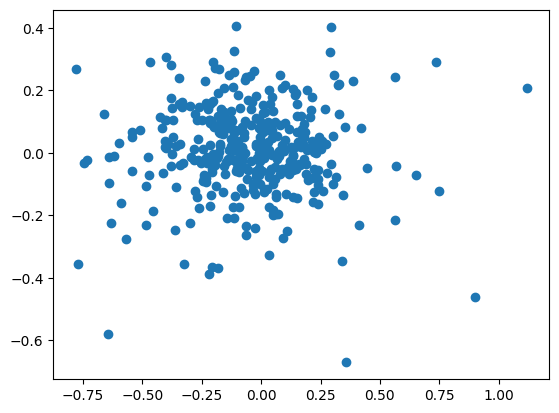

In [ ]:
cell_loadings = perturbseq_guide.median(params)["cell_loading"]

plt.scatter(
    cell_loadings[0, :],
    cell_loadings[1, :],
)
# plt.scatter(
#     cell_loadings[0, :],
#     cell_loadings[1, :],
# )

In [ ]:
param_medians = perturbseq_guide.median(params)
gene_params_df = pd.DataFrame(
    {
        "gene": genes,
        "mean": param_medians["mean"],
        "dispersion": param_medians["dispersion"] if "dispersion" in param_medians else 1,
    }
)
gene_params_df

,gene,mean,dispersion
0,ACTB,19.346952,11.565777
1,ACTG1,7.133358,3.932067
2,ACYP1,1.287627,8.185777
3,ADIPOR1,2.626769,15.735607
4,ALDH1A2,2.463416,2.359867
...,...,...,...
368,ZC3H8,0.807476,9.609318
369,ZNF273,0.580365,4.540976
370,ZNF593,5.414789,14.280106
371,ZNHIT1,4.562513,22.583126


[]

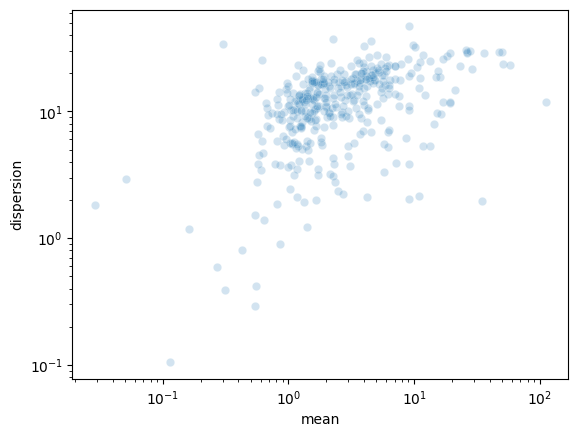

In [ ]:
sns.scatterplot(gene_params_df, x="mean", y="dispersion", alpha=0.2)
plt.loglog()

(array([229., 247., 166.,  78.,  28.,   6.,   3.,   4.,   0.,   1.]),
 array([0.00200793, 0.03211905, 0.06223017, 0.09234128, 0.12245241,
        0.15256353, 0.18267465, 0.21278577, 0.24289688, 0.27300799,
        0.30311912]),
 <BarContainer object of 10 artists>)

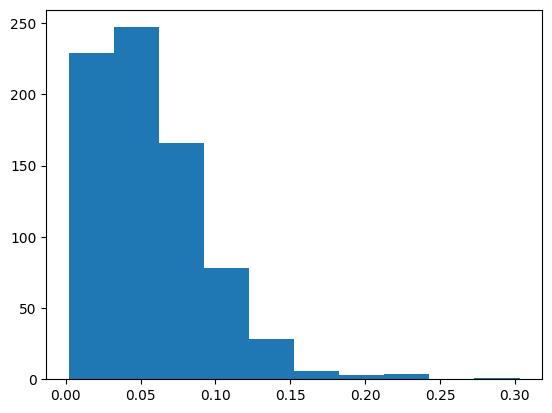

In [ ]:
plt.hist(perturbseq_guide.median(params)["efficiency"].ravel())

(381, 373)

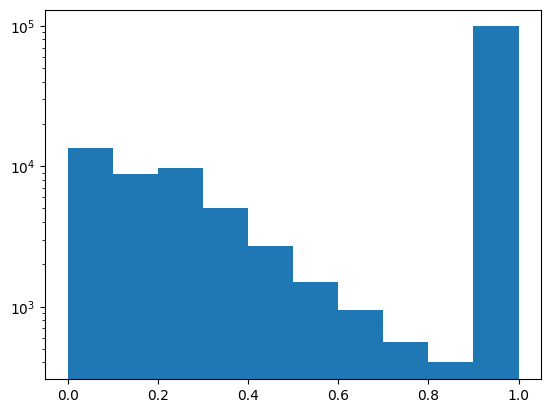

In [ ]:
from scipy.stats import norm

alpha = 1e-5
threshold = 0.3

# if "log2_fold_change_auto_loc" in params:
mu = params["log2_fold_change_auto_loc"]
sigma = params["log2_fold_change_auto_scale"]
# else:
# sigma = jnp.sqrt(params["factor_auto_loc"]**2 * params["loading_auto_scale"]**2 + params["loading_auto_loc"]**2 * params["factor_auto_scale"])
p = norm.cdf(threshold, loc=mu, scale=sigma) - norm.cdf(-threshold, loc=mu, scale=sigma)
# p = norm.sf(-threshold, loc=mu, scale=sigma)
# plt.hist(jnp.log(p+1e-10).ravel())
plt.hist(p.ravel())
plt.semilogy()
p.shape

In [ ]:
negative_pairs = perturbseq_guide.quantiles(params, 1 - alpha)["log2_fold_change"][0, ...] < -threshold
positive_pairs = perturbseq_guide.quantiles(params, alpha)["log2_fold_change"][0, ...] > threshold
# significant_pairs = negative_pairs | positive_pairs
# significant_pairs = negative_pairs
# significant_pairs = significant_pairs & sufficiently_expressed
significant_pairs = p < alpha
significant_pairs.mean()

0.008169555213105065

In [ ]:
element_idxs, gene_idxs = jnp.where(significant_pairs)
significant_pairs_df = pd.DataFrame(
    {"gene": [genes[i] for i in gene_idxs], "element": [selected_elements.values[i] for i in element_idxs]}
)

pairs_df = (
    pd.DataFrame(p, columns=genes, index=selected_elements)
    .melt(value_name="post_prob", var_name="gene", ignore_index=False)
    .reset_index(names="element")
)
significant_pairs_df = pairs_df.query("post_prob<0.01").assign(
    is_target=lambda x: x["gene"] == x["element"].str.split("_").str[0]
)
significant_pairs_df
# for a, b in zip(*):
# print(selected_elements.values[a], genes[b])
# selected_elements

,element,gene,post_prob,is_target
0,ACTB_TSS,ACTB,0.000000e+00,True
1,ACTG1_TSS,ACTB,1.173827e-04,False
27,BUB3_TSS,ACTB,4.568240e-03,False
41,CCT5_TSS,ACTB,2.616243e-09,False
46,CENPW_TSS,ACTB,2.987575e-03,False
...,...,...,...,...
142090,UBE2D2_TSS,ZRANB2,6.880365e-03,False
142099,VAPA_TSS,ZRANB2,1.941867e-03,False
142100,VDAC1_TSS,ZRANB2,6.849076e-03,False
142108,ZC3H8_TSS,ZRANB2,5.405779e-03,False


In [ ]:
significant_pairs_df.query("is_target")

,element,gene,post_prob,is_target
0,ACTB_TSS,ACTB,0.000000e+00,True
382,ACTG1_TSS,ACTG1,0.000000e+00,True
764,ACYP1_TSS,ACYP1,7.899237e-13,True
1146,ADIPOR1_TSS,ADIPOR1,0.000000e+00,True
1528,ALDH1A2_TSS,ALDH1A2,0.000000e+00,True
...,...,...,...,...
140202,YWHAQ_TSS,YWHAQ,0.000000e+00,True
140584,ZC3H8_TSS,ZC3H8,1.629807e-13,True
141348,ZNF593_TSS,ZNF593,0.000000e+00,True
141730,ZNHIT1_TSS,ZNHIT1,0.000000e+00,True


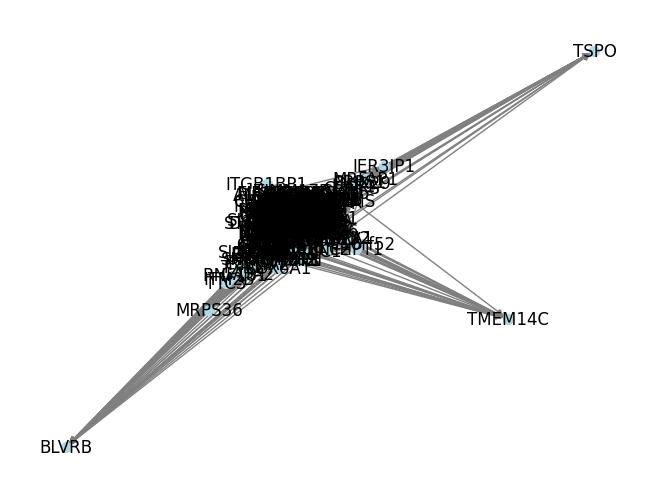

In [ ]:
import networkx as nx

significant_pairs_df.query("~is_target")
trans_effect_network = significant_pairs_df.query("~is_target").assign(
    element_gene=lambda x: x["element"].str.split("_").str[0]
)

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges
for _, row in trans_effect_network.iterrows():
    G.add_edge(row["element_gene"], row["gene"], weight=-np.log(row["post_prob"] + 1e-8))

# Draw the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=50, node_color="lightblue", edge_color="gray", arrows=True)

# Show the graph
plt.show()

In [ ]:
significant_pairs_df.value_counts("gene").reset_index()

,gene,count
0,LGALS1,83
1,HBD,79
2,TMSB4X,74
3,SH3BGRL3,71
4,NMU,63
...,...,...
368,UQCR11,5
369,PSMB6,5
370,DNAJB6,5
371,POMP,5


In [ ]:
significant_pairs_df.value_counts("element").reset_index().head(20)

,element,count
0,DDX3X_TSS,129
1,ZC3H8_TSS,78
2,EIF4G2_TSS,76
3,TMED10_TSS,76
4,MRPL16_TSS,75
5,RBMX_TSS,75
6,EIF3D_TSS,69
7,IMPDH2_TSS,68
8,RBM17_TSS,67
9,DIMT1_TSS,66


In [ ]:
", ".join(significant_pairs_df.query("element=='RABGGTB_TSS'")["gene"])
# ", ".join(significant_pairs_df.query("gene=='HBD'")["element"])

# list(significant_pairs_df.query("element=='EIF4H_TSS'")["gene"])
# list(significant_pairs_df.query("element=='EIF3A_TSS'")["gene"])
# list(significant_pairs_df.query("element=='RBM17_TSS'")["gene"])

'ACTB, APLP2, ARL4A, BLVRB, CCDC86, CCT5, CD46, CERS2, CHCHD10, CHCHD3, CHMP1B, CKB, CNBP, CSNK1A1, CTCFL, DECR1, EEF2, EIF2S2, EIF4A3, EPB41, FAM133B, FAM204A, GNAI3, GTF3A, ID3, IMPDH2, ITM2B, KCNH2, KRT18, LDHB, LGALS1, LMO2, MCM3, MRFAP1, MSN, NASP, NDUFA2, NDUFB7, NEK2, NMU, NPM1, NUDC, ODC1, PAICS, PRAME, PSMA7, RABGGTB, RBM17, RHAG, RPL18A, RPL29, RTN3, SDHC, SEC11A, SLC16A1, SLC25A33, SPCS2, TIMP1, TMED10, TMEM14A, TMPO, TUBB, UAP1, UBC, WDR61, ZNF593'

In [ ]:
", ".join(significant_pairs_df.query("element=='TMED10_TSS'")["gene"])

'ADIPOR1, ALDH1A2, BRI3, BROX, CCDC71L, CCDC86, CCT5, CNBP, CNIH4, COPS5, CRIPT, CSNK1A1, CTCFL, CUTA, DCTPP1, DECR1, EEF1A1, EIF2S1, EIF3G, FH, GADD45A, GATA2, GNPDA1, GUK1, HBD, HDGF, HHEX, HOXB2, ID1, IER3IP1, IMPDH2, INSIG1, KCNK1, KRT18, LMO2, LSM3, LYPLA1, MAX, MBOAT2, MED10, MPC1, MSN, MYL12A, MYL4, NEK2, NSL1, NUDT4, NUDT5, NUS1, PDIA4, PMAIP1, PPP1R11, PTTG1, PYCR2, RAB7A, RAN, RER1, RMI2, RPL31, SCCPDH, SH3BGRL3, SLC25A4, SMARCC1, SMC3, SSR3, TBCA, TFRC, TIMM10, TIMM17B, TMED10, TMEM167A, TTC3, TYMS, VAPA, YWHAQ, ZNHIT1'

In [ ]:
# z_vals = params["log2_fold_change_auto_loc"] / params["log2_fold_change_auto_scale"]
# z_vals
perturbseq_guide.median(params)["factor"].max()

KeyError: 'factor'

In [ ]:
# plt.ecdf(perturbseq_guide.quantiles(params, 0.95)["log2_fold_change"].reshape(-1))
# plt.xlim(-1, 1)
# plt.show()
perturbseq_guide.median(params)["loading"].shape
plt.hist(perturbseq_guide.median(params)["loading"][:, :5].T)

KeyError: 'loading'

(array([[  1.,   0.,   0.,   3.,   2.,   5., 203., 164.,   2.,   1.],
        [  0.,   0.,   0.,   0.,   0.,   0., 235., 146.,   0.,   0.],
        [  0.,   0.,   0.,   1.,   1.,  16., 184., 164.,  11.,   4.],
        [  0.,   0.,   0.,   0.,   0.,   0., 245., 136.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0., 244., 136.,   0.,   1.]]),
 array([-0.74937969, -0.64179629, -0.53421289, -0.42662948, -0.31904608,
        -0.21146269, -0.10387929,  0.00370411,  0.11128751,  0.21887091,
         0.32645431]),
 <a list of 5 BarContainer objects>)

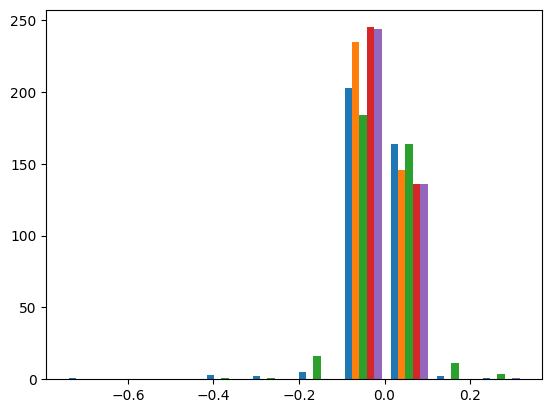

In [ ]:
perturbseq_guide.median(params)["factor"].shape
plt.hist(perturbseq_guide.median(params)["factor"][:, :5].T)

(array([  4.,  15.,  44., 110., 164., 166., 163.,  62.,  24.,  10.]),
 array([0.70105082, 0.70925736, 0.71746391, 0.72567046, 0.733877  ,
        0.74208355, 0.7502901 , 0.75849664, 0.76670319, 0.77490973,
        0.78311628]),
 <BarContainer object of 10 artists>)

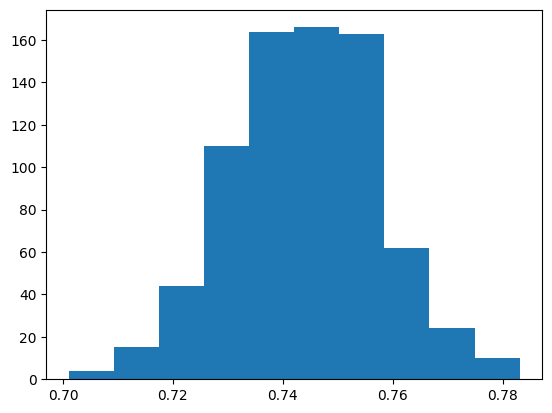

In [ ]:
# perturbseq_guide.median(params)["loading"].shape
plt.hist(perturbseq_guide.median(params)["efficiency"].ravel())

# perturbseq_guide.median(params)["loading"]

[]

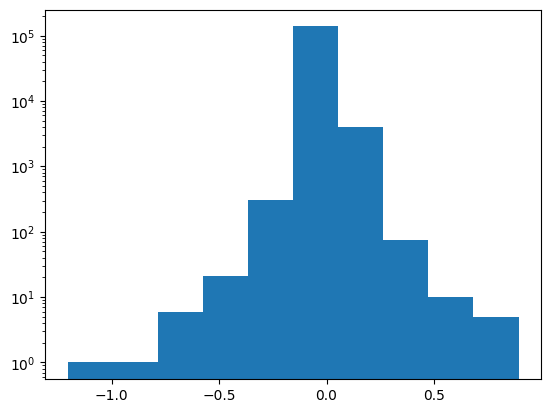

In [ ]:
factorized_lfc = perturbseq_guide.median(params)["factor"] @ perturbseq_guide.median(params)["loading"]
plt.hist(factorized_lfc.ravel())
plt.semilogy()

In [ ]:
perturbseq_guide.median(params)["factor"]

Array([[-0.00072376,  0.02089109, -0.01731775, ..., -0.00341133,
        -0.00175158,  0.00694987],
       [ 0.00969607,  0.00978827, -0.02691479, ...,  0.01781073,
        -0.00924164,  0.07638465],
       [ 0.05030981, -0.01058221, -0.00198634, ...,  0.02192942,
        -0.00450115,  0.00666643],
       ...,
       [ 0.01466117,  0.02284497, -0.01772764, ...,  0.0028587 ,
         0.00316629, -0.0135666 ],
       [ 0.04228158,  0.00898542,  0.02164154, ..., -0.04518545,
         0.02479817,  0.01003235],
       [ 0.02588904, -0.01273627,  0.03105203, ...,  0.0861553 ,
         0.00321655,  0.15997332]], dtype=float32)

(array([  1.,   3.,  10.,  27., 256.,  67.,  10.,   5.,   0.,   2.]),
 array([-0.14922081, -0.11748844, -0.08575608, -0.05402371, -0.02229134,
         0.00944103,  0.04117339,  0.07290576,  0.10463813,  0.13637049,
         0.16810286]),
 <BarContainer object of 10 artists>)

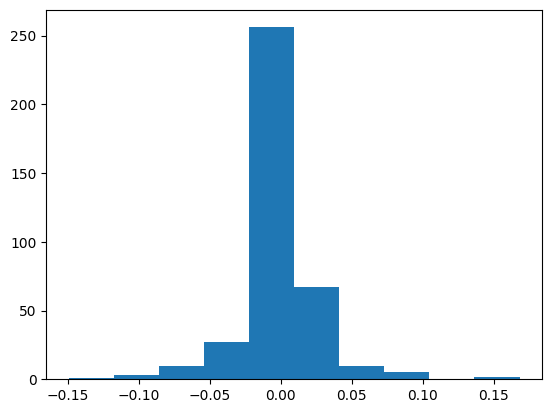

In [ ]:
factorized_ontarget = jnp.sum(element_target_genes.values.T * factorized_lfc, axis=1)
plt.hist(factorized_ontarget)

In [ ]:
factorized_lfc * 10

Array([[ 1.68102860e+00,  8.94250011e+00,  1.74740031e-01, ...,
        -1.92219287e-01,  3.70621234e-01, -1.14827931e-01],
       [-1.31923053e-02,  9.98542011e-02, -1.26637314e-02, ...,
         2.04331055e-02,  2.04616487e-01,  3.62237431e-02],
       [-2.60272902e-02,  8.07614923e-02, -4.89711091e-02, ...,
        -4.06092405e-02,  3.22749168e-02, -5.07036895e-02],
       ...,
       [ 3.59430304e-03, -4.81155887e-02,  4.54316698e-02, ...,
        -8.87011364e-03, -1.54050484e-01, -4.61182781e-02],
       [ 9.05946270e-02, -3.42364192e-01, -1.13325156e-01, ...,
        -4.72600639e-01, -3.47705901e-01, -3.00972104e-01],
       [ 3.04390907e-01,  3.44789997e-02, -2.27572508e-02, ...,
        -2.33899653e-01,  1.74434185e-01, -1.98874846e-02]],      dtype=float32)

In [ ]:
significant_pairs_df.query("gene=='EEF1A1'")

,gene,element


In [ ]:
if test_ntcs:
    significant_pairs_df[significant_pairs_df["element"].str.contains("random|scrambled", regex=True)].value_counts(
        "gene"
    )

In [ ]:
significant_pairs_df.value_counts("gene").reset_index()

,gene,count
0,HBD,16
1,DLK1,5
2,CKB,4
3,GAL,4
4,MYL4,4
...,...,...
335,INSIG1,1
336,IMPDH2,1
337,IER3IP1,1
338,HOXB2,1


[]

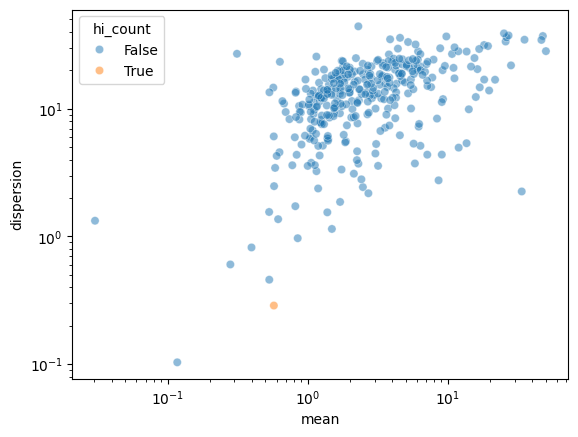

In [ ]:
sns.scatterplot(
    gene_params_df.merge(significant_pairs_df.value_counts("gene").reset_index()).assign(
        hi_count=lambda x: x["count"] > 5
    ),
    x="mean",
    y="dispersion",
    hue="hi_count",
    alpha=0.5,
)
plt.loglog()
# significant_pairs_df.value_counts("gene").reset_index()

In [ ]:
significant_pairs_df.value_counts("gene")

gene
ACTB    360
Name: count, dtype: int64

In [ ]:
significant_pairs_df.value_counts("element").head(20)

element
ACTB_TSS       1
RBMX_TSS       1
RBBP4_TSS      1
RAN_TSS        1
RABGGTB_TSS    1
RAB7A_TSS      1
PYCR2_TSS      1
PTTG1_TSS      1
PTP4A2_TSS     1
PSMG4_TSS      1
PSMG2_TSS      1
PSMG1_TSS      1
PSMB6_TSS      1
PSMA7_TSS      1
PSMA1_TSS      1
PRR13_TSS      1
PRPS1_TSS      1
PRPF38A_TSS    1
PRKCB_TSS      1
PRKAR2B_TSS    1
Name: count, dtype: int64

In [ ]:
np.mean(significant_pairs_df["gene"] == significant_pairs_df["element"].str.split("_").str[0])
# n_ontarget/len(signifi)

0.002777777777777778